# From ECG to HR and simple HRV (Principles: vagal tone, RSA)

## TODOs

1. Compute RMSSD and HF power during baseline vs stress masks. 
2. Describe which increases/decreases and why (vagal withdrawal during stress → lower RMSSD/HF).

## My notes

+ RMSSD (Root Mean Square of Successive Differences)
    - Calculate using the R-peaks, where these R-peaks are the heartbeats.
    - R-peaks come from ECG, where ECG has P-wave, QRS-complex, and T-wave.
    - Time domain.
    - Steps:
        1. From the ECG, detect the components: P-wave, QRS-complex, and T-wave. 
        2. Delineate ECG for R-peaks, where these R-peaks are the heartbeats
        3. Calculate RMSSD by passing in R-peaks to get HRV
            - 3.1 1 R-peak = 1 Heartbeat
            - 3.2 Consecutive R-peaks are RR-interval = consecutive HBs
                - 3.2.1  From RR-interval, calculate LF/HF
    - We want this value to be
        1. high bc it leads to better recovery + more ANS stimulaton?
            - high means more time between heartbeats
        2. varied bc it leads to better recovery
+ HF (High Frequency) power
    1. Frequency domain.
    2. Favors parasympathetic activity, which is rest and recovery/digest.
    3. We want this value to be high bc...

## Code

In [1]:
import os
import pickle

import numpy as np
import pandas as pd

import neurokit2 as nk

import matplotlib.pyplot as plt

from tqdm import tqdm

from scipy.interpolate import interp1d
from scipy.signal import find_peaks, welch
from adtk.data import validate_series
from adtk.detector import ThresholdAD

notebook_dir = os.getcwd()

## Load Data

In [2]:
data_path = os.path.join(notebook_dir, "../../../data/WESAD/all_subjects/chest.csv")
df = pd.read_csv(data_path)
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [3]:
def get_per_subject(df):
    per_subject = {}
    entries = df['subject'].unique()
    for entry in entries:
        filt_subject = (df['subject'] == entry)
        subject_df = df[filt_subject]
        subject_df.reset_index(inplace=True)
        per_subject[entry] = subject_df
    return per_subject

In [4]:
per_subject_dfs = get_per_subject(df)
per_subject_dfs

{'S2':            index   ACC_x   ACC_y   ACC_z       ECG       EMG       EDA  \
 0              0  0.9554 -0.2220 -0.5580  0.021423 -0.004440  5.250549   
 1              1  0.9258 -0.2216 -0.5538  0.020325  0.004349  5.267334   
 2              2  0.9082 -0.2196 -0.5392  0.016525  0.005173  5.243301   
 3              3  0.8974 -0.2102 -0.5122  0.016708  0.007187  5.249405   
 4              4  0.8882 -0.2036 -0.4824  0.011673 -0.015152  5.286407   
 ...          ...     ...     ...     ...       ...       ...       ...   
 4255295  4255295  0.8750 -0.1234 -0.2974 -0.013138  0.020370  0.400162   
 4255296  4255296  0.8750 -0.1262 -0.2988 -0.010345  0.019592  0.355911   
 4255297  4255297  0.8718 -0.1238 -0.3042 -0.005447 -0.017166  0.360489   
 4255298  4255298  0.8730 -0.1234 -0.3026  0.000137 -0.028976  0.365829   
 4255299  4255299  0.8702 -0.1220 -0.3022  0.004074 -0.023575  0.365448   
 
               Temp      Resp subject  label  
 0        30.120758 -1.148987      S2      0 

In [5]:
s_df = per_subject_dfs['S7']
s_df

,index,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,22626800,1.0696,-0.0140,1.4612,-0.019226,-0.048843,12.506866,33.993530,1.832581,S7,0
1,22626801,1.0654,-0.0102,1.4222,-0.016937,-0.007004,12.468719,33.932680,1.835632,S7,0
2,22626802,1.0654,0.0042,1.3202,-0.016159,0.071777,12.506866,33.970703,1.856995,S7,0
3,22626803,1.0666,0.0202,1.1464,-0.012405,0.088486,12.506485,34.008760,1.829529,S7,0
4,22626804,1.0602,0.0310,0.9192,-0.020325,0.090271,12.504959,33.887085,1.817322,S7,0
...,...,...,...,...,...,...,...,...,...,...,...
3666595,26293395,0.8586,-0.0958,-0.0390,0.156418,-0.036942,13.085556,34.917084,0.813293,S7,0
3666596,26293396,0.8526,-0.1026,-0.0430,0.115723,0.098831,13.089371,34.935608,0.816345,S7,0
3666597,26293397,0.8466,-0.1082,-0.0574,0.086380,0.199768,13.090134,34.943300,0.804138,S7,0
3666598,26293398,0.8422,-0.1138,-0.0814,0.139938,0.227646,13.081360,34.940247,0.834656,S7,0


In [6]:
subset_data = False

if subset_data == True:
    # subset_data_N = 126000
    subset_data_N = 21000
    series = s_df.loc[:subset_data_N, "ECG"]
    print(len(series), series)
else:
    series = s_df.loc[:, "ECG"].values
    print(len(series), series)


3666600 [-0.01922607 -0.01693726 -0.01615906 ...  0.08638     0.13993835
  0.23899841]


In [7]:
cleaned_series = nk.ecg_clean(series, 700)
cleaned_series

array([ 0.04248399,  0.03589075,  0.02932948, ..., -0.24272866,
       -0.22280181, -0.2019248 ], shape=(3666600,))

In [8]:
n_segments = 87
segments = np.array_split(cleaned_series, n_segments)
len(segments[0])

42145

In [9]:
segments_df = pd.DataFrame(segments)
segments_df

,0,1,2,3,4,5,6,7,8,9,...,42135,42136,42137,42138,42139,42140,42141,42142,42143,42144
0,0.042484,0.035891,0.029329,0.022990,0.017082,0.011978,0.007969,0.005041,0.003545,0.003587,...,0.131465,0.204956,0.286829,0.376087,0.471287,0.570656,0.671805,0.770718,0.863458,0.946223
1,1.015747,1.069984,1.107638,1.127876,1.130059,1.113781,1.078870,1.025423,0.953846,0.864750,...,-0.535782,-0.524993,-0.509893,-0.491464,-0.470573,-0.447993,-0.424450,-0.400533,-0.376734,-0.353431
2,-0.330964,-0.309627,-0.289617,-0.271021,-0.253869,-0.238173,-0.223879,-0.210902,-0.199156,-0.188567,...,-0.060470,-0.060111,-0.059685,-0.059135,-0.058487,-0.057763,-0.056980,-0.056182,-0.055377,-0.054589
3,-0.053817,-0.053043,-0.052318,-0.051690,-0.051134,-0.050660,-0.050255,-0.049901,-0.049550,-0.049161,...,1.038934,0.966266,0.877362,0.773280,0.658265,0.536743,0.412740,0.289344,0.169006,0.053781
4,-0.054512,-0.154329,-0.244482,-0.323956,-0.391883,-0.447546,-0.490393,-0.520114,-0.538118,-0.546042,...,-0.027075,-0.026635,-0.026145,-0.025634,-0.025126,-0.024647,-0.024207,-0.023815,-0.023458,-0.023112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,-0.105110,-0.102330,-0.099613,-0.096966,-0.094395,-0.091915,-0.089516,-0.087186,-0.084912,-0.082672,...,-0.482445,-0.460480,-0.437621,-0.414546,-0.391863,-0.370016,-0.349312,-0.329941,-0.311965,NaN
83,-0.295398,-0.280254,-0.266486,-0.253968,-0.242538,-0.232071,-0.222505,-0.213824,-0.205991,-0.198940,...,-0.050975,-0.048196,-0.045462,-0.042774,-0.040131,-0.037542,-0.035004,-0.032524,-0.030112,NaN
84,-0.027767,-0.025490,-0.023261,-0.021046,-0.018832,-0.016608,-0.014379,-0.012138,-0.009895,-0.007641,...,0.136634,0.139493,0.142314,0.145095,0.147857,0.150597,0.153309,0.155966,0.158574,NaN
85,0.161127,0.163582,0.165905,0.168097,0.170185,0.172140,0.174000,0.175814,0.177600,0.179363,...,-0.002295,-0.011476,-0.020481,-0.029261,-0.037749,-0.045943,-0.053841,-0.061433,-0.068728,NaN


- > Each row represents a segment, so 174 rows = 174 segments
- > Each segment has a lenght of 21073
- > We want to compare across segments

<Axes: >

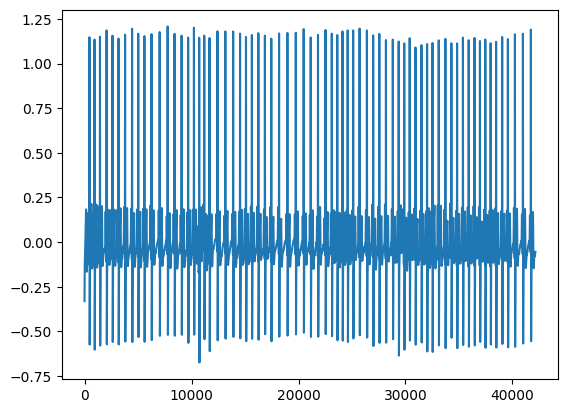

In [10]:
segments_df.iloc[2, :].plot.line()

87it [00:00, 978.53it/s]


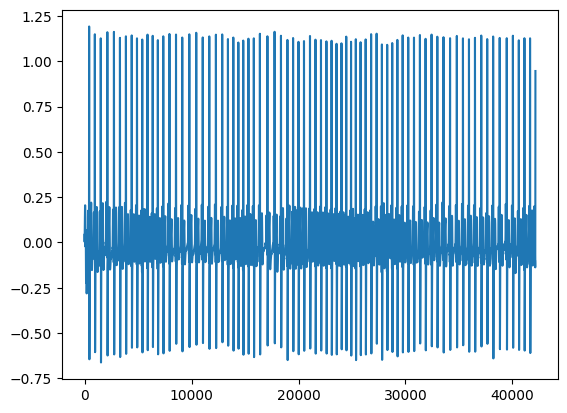

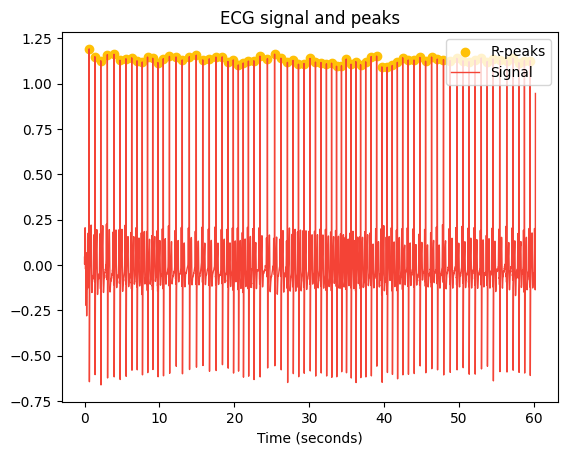

In [11]:
r_peaks_data = []
for idx, segment in tqdm(segments_df.iterrows()):
    if idx == 0: 
        # print(segment)
        segment.plot.line()
        r_peaks_in_segment = nk.ecg_peaks(segment, sampling_rate=700, show=True)
        r_peaks_data.append(r_peaks_in_segment)
    if idx > 0:
        r_peaks_in_segment = nk.ecg_peaks(segment, sampling_rate=700)
        r_peaks_data.append(r_peaks_in_segment)

In [12]:
r_peaks_df, r_peaks_info = r_peaks_data[0]
r_peaks_info

{'method_peaks': 'neurokit',
 'method_fixpeaks': 'None',
 'ECG_R_Peaks': array([  433,   965,  1518,  2134,  2750,  3312,  3869,  4411,  4904,
         5395,  5889,  6373,  6854,  7360,  7937,  8551,  9133,  9794,
        10442, 11050, 11660, 12280, 12869, 13405, 13906, 14376, 14834,
        15319, 15824, 16392, 17094, 17764, 18361, 18964, 19493, 19998,
        20513, 21074, 21586, 22101, 22609, 23091, 23554, 24015, 24462,
        24910, 25357, 25802, 26278, 26787, 27300, 27795, 28289, 28759,
        29239, 29736, 30255, 30794, 31349, 31877, 32437, 32974, 33551,
        34164, 34798, 35370, 35933, 36494, 37080, 37637, 38192, 38805,
        39464, 40039, 40593, 41116, 41642]),
 'sampling_rate': 700}

In [13]:
r_peaks_df

,ECG_R_Peaks
0,0
1,0
2,0
3,0
4,0
...,...
42140,0
42141,0
42142,0
42143,0


> r_peaks are 1 and non-r_peaks = 0

In [14]:
filt_r_peaks = (r_peaks_df['ECG_R_Peaks'] == 1)
true_r_peaks_df = r_peaks_df[filt_r_peaks]
true_r_peaks_df

,ECG_R_Peaks
433,1
965,1
1518,1
2134,1
2750,1
...,...
39464,1
40039,1
40593,1
41116,1


In [15]:
r_peak_values = segments_df.iloc[0, r_peaks_info['ECG_R_Peaks']].values
r_peak_values

array([1.19196633, 1.14895008, 1.12652599, 1.16040058, 1.16216153,
       1.12925984, 1.13764634, 1.14259749, 1.12645015, 1.11983566,
       1.14697247, 1.14044584, 1.11656175, 1.13772621, 1.15056613,
       1.1473775 , 1.13099897, 1.14870668, 1.15723434, 1.13144963,
       1.13717467, 1.14671145, 1.14810962, 1.12250975, 1.13088417,
       1.10338107, 1.11420427, 1.12461353, 1.12659837, 1.15178645,
       1.13789455, 1.16270119, 1.14083684, 1.11778114, 1.12826772,
       1.10722326, 1.11133071, 1.1395047 , 1.11922416, 1.1168365 ,
       1.10987608, 1.11316307, 1.09642901, 1.0990712 , 1.13588288,
       1.10756271, 1.12160304, 1.10495551, 1.12059372, 1.14949429,
       1.15217581, 1.09277357, 1.09074873, 1.10049584, 1.11787735,
       1.14299525, 1.13081754, 1.13049069, 1.14481487, 1.12386981,
       1.14714744, 1.13548481, 1.13272437, 1.12716315, 1.13972221,
       1.12639975, 1.12133692, 1.12947727, 1.14193203, 1.12241385,
       1.13658461, 1.12875166, 1.12726167, 1.14093404, 1.11558

/Users/detraviousjamaribrinkley/Documents/Development/research_labs/roeh_labs/health/closed_loop_wearable_therapies/lamina/lamina/.venv/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,774.605263,85.188418,NaN,NaN,NaN,NaN,NaN,NaN,53.003915,53.360723,...,2.061423,5.958454,1.058371,1.035216,0.965548,1.478378,1.744425,1.588671,2.378666,0.904305


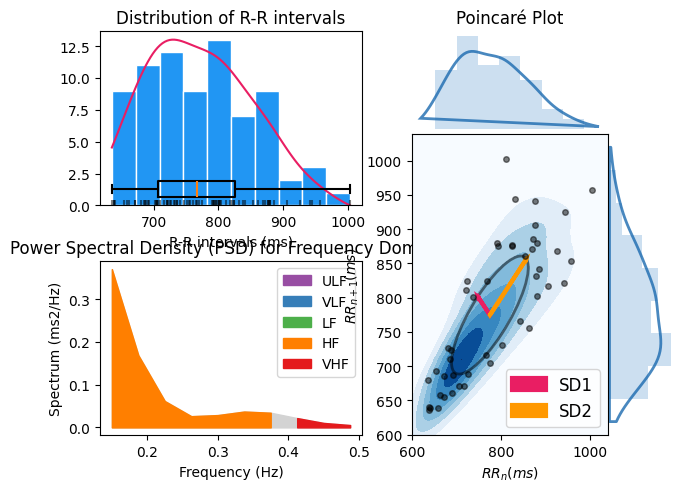

In [16]:
# nk.hrv(r_peak_values, sampling_rate=700, show=True)
stats_0_df = nk.hrv(r_peaks_df, sampling_rate=700, show=True)
stats_0_df

In [24]:
def get_rmssd(df): 
    rmssd_value = df.HRV_RMSSD
    # print(rmssd_value)
    return rmssd_value


In [25]:
stats_0_rmssd = get_rmssd(stats_0_df)
stats_0_rmssd

0    53.003915
Name: HRV_RMSSD, dtype: float64

In [19]:
r_peaks_1_df, r_peaks_1_info = r_peaks_data[1]
r_peaks_1_info

{'method_peaks': 'neurokit',
 'method_fixpeaks': 'None',
 'ECG_R_Peaks': array([  511,   988,  1461,  1929,  2407,  2916,  3539,  4188,  4849,
         5477,  6117,  6744,  7368,  7987,  8565,  9164,  9832, 10503,
        11177, 11840, 12526, 13201, 13838, 14438, 14986, 15494, 16017,
        16531, 17142, 17890, 18567, 19201, 19855, 20475, 21141, 21848,
        22494, 23152, 23863, 24567, 25210, 25886, 26545, 27152, 27796,
        28414, 28976, 29503, 30013, 30495, 30998, 31526, 32035, 32521,
        33003, 33463, 33948, 34565, 35110, 35611, 36095, 36572, 37050,
        37522, 38300, 38983, 39590, 40235, 40895, 41547, 42109]),
 'sampling_rate': 700}

/Users/detraviousjamaribrinkley/Documents/Development/research_labs/roeh_labs/health/closed_loop_wearable_therapies/lamina/lamina/.venv/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


0    84.277994
Name: HRV_RMSSD, dtype: float64

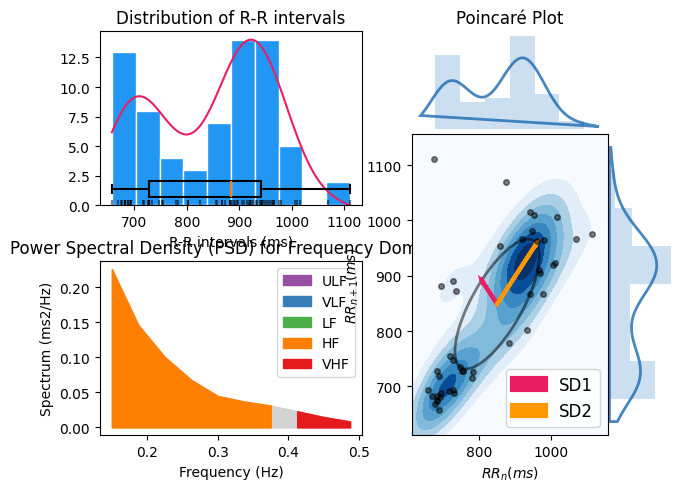

In [26]:
stats_1_df = nk.hrv(r_peaks_1_df, sampling_rate=700, show=True)
stats_1_df
stats_1_rmssd = get_rmssd(stats_1_df)
stats_1_rmssd

In [32]:
rmssd_df = pd.DataFrame([stats_0_rmssd.values, stats_1_rmssd])
rmssd_df

,0
0,53.003915
1,84.277994


<Axes: >

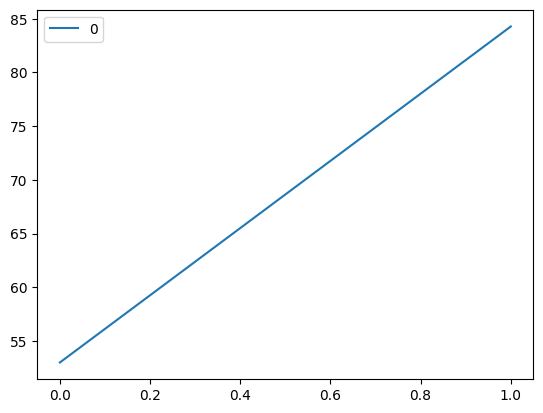

In [34]:
rmssd_df.plot.line()

## Follow-Up

> - Be sure to see TODOs

1. What do we gather from this subject?
2. Is there anything to flag?
3. 'RMSSD_ms': np.float64(698.4470516017469)
    - Why?
    - Good/Bad?
4. 'HF': np.float64(0.04114562090390898), why?
    - Why?
    - Good/Bad?
5. RMSSD_ms and HF considered jointly
    - If one is good and other bad? Vice versa
    - If both are good? Both are bad?

### 1. What do we gather from this subject?

> - R-peaks (aka heartbeats in green).


In [ ]:
# Could say something based on the avg of the window of 60 secs or take last

# Choose sampling rate and adjustable
# 